In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_original=pd.read_csv("flock_history.csv")
df_original.head()

,step,boid_id,pos_x,pos_y,pos_z,vel_x,vel_y,vel_z,u_x,u_y,u_z
0,0,0,29.471674,7.526538,24.769407,2.662730,0.105471,-0.748391,-0.331485,0.060640,-0.714835
1,0,1,34.732996,35.234441,3.242230,2.806319,0.035041,1.023160,-0.187896,-0.009790,1.056716
2,0,2,36.187474,2.042128,15.268155,2.981106,0.094524,-0.224110,-0.013109,0.049692,-0.190554
3,0,3,22.372297,37.644770,19.355962,2.958629,0.685955,-0.145016,-0.035586,0.641124,-0.111460
4,0,4,24.511608,7.377016,3.602307,3.678531,0.037950,-0.477895,0.684316,-0.006881,-0.444339


In [3]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

def compute_spatial_correlation(df_original, step, n_bins=50):
    # Filter the dataframe for the specific time step
    df = df_original[df_original['step'] == step]
    
    # Extract coordinates and velocity fluctuations as NumPy arrays
    pos = df[['pos_x', 'pos_y', 'pos_z']].values
    u = df[['u_x', 'u_y', 'u_z']].values
    c0 = 1
    n=len(df)
    
    r_list=[]
    uiuj_list=[]
    
    for i in range(n):
        for j in range(i+1, n):
            dist = np.sqrt((pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2 + (pos[i,2]-pos[j,2])**2)
            uiuj= u[i,0]*u[j,0] + u[i,1]*u[j,1] + u[i,2]*u[j,2]
    
            r_list.append(dist)
            uiuj_list.append(uiuj)
    
    
    df_rough = pd.DataFrame({
        'r':r_list, 
        'u_iu_j':uiuj_list
    })

    bins = np.linspace(0, df_rough['r'].max(), n_bins)
    df_rough['r_bin'] = pd.cut(df_rough['r'], bins=bins, labels=bins[:-1] + np.diff(bins)/2)

    c_r = df_rough.groupby('r_bin', observed=True)['u_iu_j'].mean()

    return c_r

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Initialize a list to store the C(r) Series for each step
all_correlations = []

# 2. Loop through all 10,000 steps
# Note: This might take a while due to the nested loops in your function
unique_steps = df_original['step'].unique()

print(f"Starting calculation for {len(unique_steps)} steps...")

for step in unique_steps:
    # Call your function exactly as defined
    res = compute_spatial_correlation(df_original, step, n_bins=50)
    all_correlations.append(res)

print(all_correlations)

Starting calculation for 1000 steps...
[r_bin
2.892107    -0.224938
4.048949     0.027332
5.205792    -0.010275
6.362635     0.069428
7.519477     0.049257
8.676320    -0.020210
9.833163    -0.016273
10.990005    0.016518
12.146848   -0.034566
13.303691   -0.013454
14.460533    0.015895
15.617376   -0.036609
16.774219    0.040105
17.931061   -0.003880
19.087904    0.012402
20.244747   -0.034514
21.401589    0.030172
22.558432    0.003885
23.715275   -0.000215
24.872117   -0.045695
26.028960   -0.023003
27.185803   -0.013830
28.342646   -0.009212
29.499488   -0.016026
30.656331    0.016577
31.813174   -0.029422
32.970016   -0.028973
34.126859   -0.034021
35.283702    0.028046
36.440544   -0.022288
37.597387   -0.027479
38.754230   -0.015453
39.911072   -0.016669
41.067915    0.069558
42.224758   -0.014228
43.381600   -0.007359
44.538443    0.013995
45.695286   -0.013239
46.852128   -0.030126
48.008971    0.125608
49.165814   -0.074287
50.322656   -0.074553
51.479499    0.138657
52.63634

Processing 1000 steps. This may take some time...


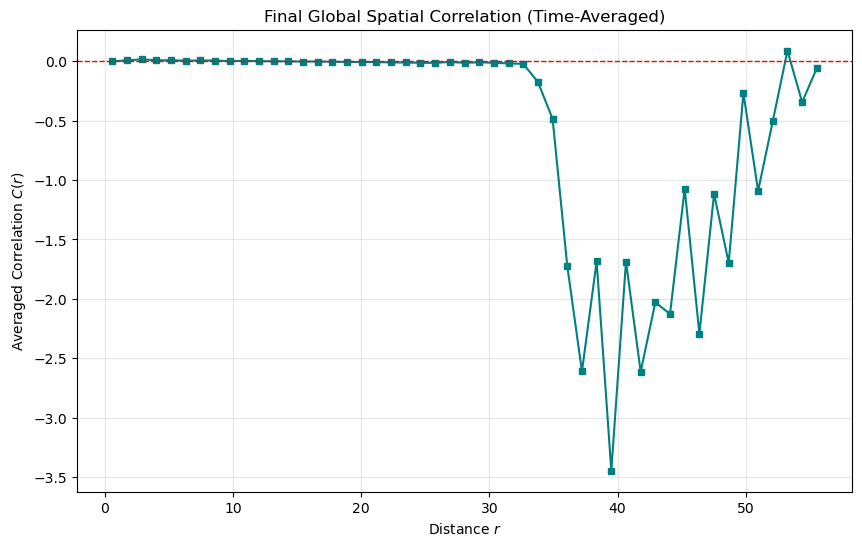

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize a list to store all (r, c_r) pairs from all steps
all_results_list = []

unique_steps = df_original['step'].unique()
print(f"Processing {len(unique_steps)} steps. This may take some time...")

# 2. Run the loop using your existing function
for step in unique_steps:
    # Your function returns a Series with r as index and C(r) as values
    res = compute_spatial_correlation(df_original, step, n_bins=50)
    
    # Convert the Series to a temporary DataFrame and reset index to get 'r' as a column
    step_df = res.reset_index()
    step_df.columns = ['r', 'c_r']
    
    all_results_list.append(step_df)

# 3. Concatenate all data into one giant "cloud" of points
# This contains every correlation value at every distance across all time
full_data = pd.concat(all_results_list, ignore_index=True)

# 4. Redo the binning and averaging on the global dataset
# We define 50 master bins from 0 to the maximum observed distance
master_bins = np.linspace(0, full_data['r'].max(), 50)
bin_centers = master_bins[:-1] + np.diff(master_bins) / 2

# Create the master bins for the whole simulation
full_data['master_r_bin'] = pd.cut(full_data['r'], bins=master_bins, labels=bin_centers)

# 5. Final Average: this is the true time-averaged C(r)
final_c_r = full_data.groupby('master_r_bin', observed=True)['c_r'].mean()

# 6. Plotting
plt.figure(figsize=(10, 6))
plt.plot(final_c_r.index, final_c_r.values, marker='s', markersize=4, linestyle='-', color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Distance $r$')
plt.ylabel('Averaged Correlation $C(r)$')
plt.title('Final Global Spatial Correlation (Time-Averaged)')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
print(max(unique_steps))

999
